# Sampling GOE and GSE soft edge scaling limit eigenvalues

In [1]:
using SkewLinearAlgebra, LinearAlgebra, SpecialFunctions, Plots, QuadGK, ForwardDiff, Distributions
import GaussQuadrature.legendre

In [2]:
function Jn(n)
    inds = [ i%2==0 ? (i+1)÷2+n : (i+1)÷2 for i in 1:2n]
    return Jn2(n)[inds, inds]
end
Jn(A::Matrix) = Jn(size(A,1)÷2)
Jn2(n) = [zeros(n, n) I ; -I zeros(n, n)]
skew_sym(A) = (A-transpose(A))/2
function pf(A)
    if norm(A+transpose(A))>1e-12 return nothing end
    return pfaffian(skew_sym(A))
end
skewtr(A) = sum(abs.(diag(A, 1)[1:2:end]))   

skewtr (generic function with 1 method)

In [3]:
function onestep_pfaffian_lu!(A, i)
    b = A[2i-1,2i]
    P = A[2i-1:2i, 2i+1:end]
    A[2i+1:end, 2i+1:end] .-= P'*Jn(1)*P/b
end
function PPPsampler(KernelK)
    sample = []
    A = copy(KernelK)
    n = size(A,1)÷2
    for i in 1:n
        if rand(Bernoulli(A[2i-1,2i]))
            push!(sample, i)
        else
            A[2i-1:2i, 2i-1:2i] .-= Jn(1)
        end
        onestep_pfaffian_lu!(A, i)
    end
    return sample
end
function PPPsampler_twolargest(KernelK)
    λ1 = 0
    A = copy(KernelK)
    n = size(A,1)÷2
    for i in 1:n
        if rand(Bernoulli(A[2i-1,2i]))
            if λ1==0 
                λ1 = i
            else
                return λ1, i
            end
        else
            A[2i-1:2i, 2i-1:2i] .-= Jn(1)
        end
        onestep_pfaffian_lu!(A, i)
    end
    return 0, 0
end

PPPsampler_twolargest (generic function with 1 method)

In [4]:
Ai, Aip = airyai, airyaiprime
function GL(m, a, b; f=legendre)
    xi, wi = f(m)
    return map( t->((a+b)/2 + t*(b-a)/2), xi ), (b-a) * wi / 2
end
GL(m) = GL(m, 0, 1)

# Usual Airy kernel and aux functions for [s, ∞) cases
K_Ai(x, y) = x==y ? (Aip(x))^2 - x * (Ai(x))^2 : (Ai(x) * Aip(y) - Ai(y) * Aip(x)) / (x - y)
ϕ(x,s) = s+10*tan(π*x/2) 
ϕp(x)  = 5π*sec(π*x/2)^2

ϕp (generic function with 1 method)

In [5]:
# QuadGK implementation, Page 10 https://www.math.ucdavis.edu/~tracy/selectedPapers/2000s/CV78.pdf 
# Modified with multiplication of 2 on (2,2) entry, 1/2 on (1,1)

IAi(x; rtol=1e-10, atol=1e-12) = quadgk(Ai, x, Inf; rtol=rtol, atol=atol)[1] # ∫ₓ^∞ Ai(z)dz
IAiyx(x, y; rtol=1e-10, atol=1e-12) = quadgk(Ai, y, x; rtol=rtol, atol=atol)[1] # ∫_y^x Ai(z)dz
IKAi(x, y; rtol=1e-10, atol=1e-12) = quadgk(z->K_Ai(z, y), x, Inf; rtol=rtol, atol=atol)[1] #∫ₓ^∞KAi(z, y)dz
DKAi(x, y) = ForwardDiff.derivative(z->K_Ai(x, z), y)
DK_Ai(x, y) = x==y ? -Ai(x)^2/2 : K_Ai(x,y)/(x-y)+(Ai(x)*Ai(y)*y-Aip(x)*Aip(y))/(x-y)


S(x, y) = K_Ai(x, y) + Ai(x)*(1-IAi(y))/2
SD(x, y) = x==y ? 0.0 : -DKAi(x, y)-Ai(x)*Ai(y)/2
IS(x, y) = -IKAi(x, y) + (IAiyx(x, y) + IAi(x)*IAi(y))/2

K_GOE(x, y) = [ -SD(x, y) S(x, y);
                -S(y, x)    (x==y ? 0.0 : IS(x, y)-sign(x-y)/2)]

function K_GSE(rx, ry) 
    x, y = sqrt(2)*rx, sqrt(2)*ry 
    return sqrt(2)*[x==y ? 0.0 : IAi(x)*IAi(y)/4-IKAi(x,y)/2 K_Ai(y,x)/2-Ai(y)*IAi(x)/4;
                Ai(x)*IAi(y)/4-K_Ai(x,y)/2 Ai(x)*Ai(y)/4+DK_Ai(x,y)/2]
end

K_GSE (generic function with 1 method)

In [6]:
function collect_K(f, x)
    m = length(x)
    K = zeros(2m, 2m)
    for i in 1:m, j in 1:m
        k = f(x[i], x[j])
        if i<j
            K[2i-1:2i, 2j-1:2j] .= k
            K[2j-1:2j, 2i-1:2i] .= -k'
        elseif i==j
            K[2i-1:2i, 2j-1:2j] .= k 
        end    
    end  
    return K
end

function collect_K_ϕ(f, m, s)
    x, w = GL(m)
    K = zeros(2m, 2m)
    for i in 1:m, j in 1:m
        if i<j
            k = f(ϕ(x[i],s), ϕ(x[j], s)) * sqrt(w[i]*w[j]) * sqrt(ϕp(x[i])*ϕp(x[j]))
            K[2i-1:2i, 2j-1:2j] .= k
            K[2j-1:2j, 2i-1:2i] .= -k'
        elseif i==j
            K[2i-1:2i, 2j-1:2j] .= f(ϕ(x[i],s), ϕ(x[j], s)) * sqrt(w[i]*w[j]) * sqrt(ϕp(x[i])*ϕp(x[j]))
        end    
    end  
    return K
end

function TW₁_CDF_ϕ(s; m=20, f=K_GOE)
    K = collect_K_ϕ(f, m, s)
    return pf(Jn(K) - K)
end

function TW₄_CDF_ϕ(s; m=20, f=K_GSE)
    K = collect_K_ϕ(f, m, s)
    return pf(Jn(K) - K)
end

### Below for cond approach
function K_cond(λ, x, y, f) # Conditional kernel
    n = length(λ)
    Px = hcat.(f.(x, λ))
    Py = vcat.(f.(λ, y))
    Kλ = zeros(2n, 2n)
    for i in 1:n, j in 1:n
        Kλ[2i-1:2i, 2j-1:2j] .= f(λ[i], λ[j])
    end
    return f(x, y) - Px * (Kλ \ Py)
end
function K_cond(λ, x, y, Kλ, f)
    Px = hcat.(f.(x, λ))
    Py = vcat.(f.(λ, y))
    return f(x, y) - Px * (Kλ \ Py)
end

K_GOE_cond(λ, x, y) = K_cond(λ, x, y, K_GOE)
K_GOE_cond(λ, Kλ, x, y) = K_cond(λ, x, y, Kλ, K_GOE)

K_GSE_cond(λ, x, y) = K_cond(λ, x, y, K_GSE)
K_GSE_cond(λ, Kλ, x, y) = K_cond(λ, x, y, Kλ, K_GSE)  

function TW₄_PDF(s; m=20, xmax=10)
    x, w = GL(m, s, xmax)
    Kλ = K_GSE(s, s)
    K = collect_K_ϕ((xi,xj)->K_GSE_cond(s,Kλ,xi,xj), m, s)
    return pf(Kλ) * pf(Jn(K) - skew_sym(K))
end

TW₄_PDF (generic function with 1 method)

In [7]:
function TW1pdf_second(s; m=30) # Second largest eigenvalue of TW1 pdf
    xs = LinRange(s, 2, m)
    dx = xs[2]-xs[1]
    Kλ = K_GOE(s, s)
    Ks = collect_K((xi,xj)->K_GOE_cond(s,Kλ,xi,xj), xs) * dx
    Ls = Jn(m)*Ks/(Jn(m)-Ks)
    return abs(Kλ[1,2] * skewtr(Ls) * pf(Jn(m)-Ks))
end
function TW4pdf_second(s; m=30) # Second largest eigenvalue of TW4 pdf
    xs = LinRange(s, 2, m)
    dx = xs[2]-xs[1]
    K = collect_K(K_GSE, xs) * dx
    Kλ = K_GSE(s, s)
    Ks = collect_K((xi,xj)->K_GSE_cond(s,Kλ,xi,xj), xs) * dx
    Ls = Jn(m)*Ks/(Jn(m)-Ks)
    return Kλ[1,2] * skewtr(Ls) * pf(Jn(m)-Ks)
end

TW4pdf_second (generic function with 1 method)

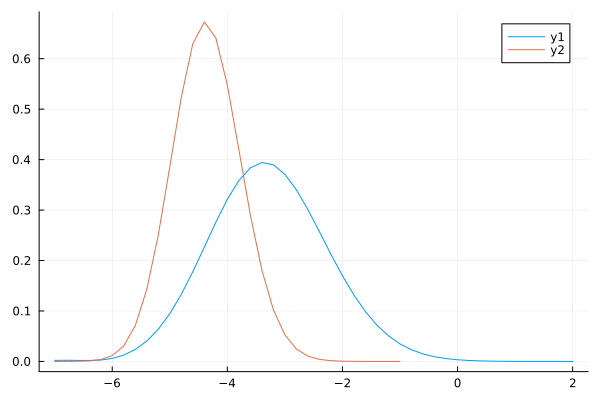

In [8]:
## Ploting the pdfs of the second larges eigenvalues of TW1, TW4

dx = 0.2
x1_2 = -7:dx:2
x4_2 = -7:dx:-1
d1_2 = TW1pdf_second.(x1_2)
d4_2 = TW4pdf_second.(x4_2)
plot(x1_2, d1_2)
plot!(x4_2, d4_2)

In [9]:
## Sampling the two largest eigenvalues for TW1, TW4

dx = 0.05
x1 = 5:-dx:-8
x4 = 2:-dx:-8
K1 = collect_K(K_GOE, x1) * dx
K4 = collect_K(K_GSE, x4) * dx;

In [11]:
d1_12 = [PPPsampler_twolargest(K1) for i in 1:1000]
d4_12 = [PPPsampler_twolargest(K4) for i in 1:1000]

GOE_second_eigvals = x1[last.(d1_12)]
GSE_second_eigvals = x4[last.(d4_12)];